# DATA PROCESSING

In [2]:
#path config set
import sys
from pathlib import Path

project_root = Path.cwd().parent
for folder in ["functions", "other"]:
    p = str(project_root / folder)
    if p not in sys.path:
        sys.path.append(p)

In [3]:
# importy kniznic
%load_ext autoreload
%autoreload 2

import warnings
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

from functions_stationarity import check_stationarity, determine_diff_orders, build_combined_dataset

from cred import DATA_PATH_CRED

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams.update({
    "figure.figsize": (18, 6),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

print("Importy uspesne.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Importy uspesne.


In [4]:
# konfiguracia a stiahnutie dat
# vypisanie info o datach a kontrola chybajucich hodnot


data = "data.xlsx"
DATA_PATH  = Path(DATA_PATH_CRED) /  data
SHEET_NAME = "all"

df_raw = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME, engine="openpyxl")

df_raw["datum"] = pd.to_datetime(df_raw["datum"])
df_raw = df_raw.set_index("datum").sort_index()
df_raw = df_raw.asfreq("MS")

print(f"Nacitane: {df_raw.shape[0]} riadkov, {df_raw.shape[1]} stlpcov")
print(f"Obdobie : {df_raw.index.min().date()} az {df_raw.index.max().date()}")
print("Stlpce  :", list(df_raw.columns))

missing = df_raw.isnull().sum()
if missing.any():
    print("\nChybajuce hodnoty:")
    print(missing[missing > 0])
else:
    print("\nZiadne chybajuce hodnoty.")

df = df_raw.copy()


Nacitane: 312 riadkov, 29 stlpcov
Obdobie : 2000-01-01 az 2025-12-01
Stlpce  : ['pp_non_sa', 'pp_sa_orig', 'cpi_non_sa', 'cpi_sa', 'infl_cpi', 'ipcv_priemysel', 'export_celkovy_sa', 'trzby_priemysel_sa', 'kurz_usd_eur', 'sadzba_3m_euribor', 'uvery_celkom', 'vklady_nefinancne_podniky', 'fin_stock', 'pp_sa_ca_jd', 'unem_prod', 'inflation', 'cdd', 'hdd', 'sh_prices_non_sa', 'economic_sentiment', 'industry_confidence_sa', 'current_total_demand_sa', 'foreign_demand_sa', 'finished_goods_inventories_sa', 'expected_industry_production', 'expected_product_prices', 'expected_employment', 'oil_europe_usd', 'oil_europe_eur']

Ziadne chybajuce hodnoty.


In [35]:
df_subset = df.loc["2020-03-01":"2020-05-01"]

In [36]:
df_subset[["pp_non_sa","pp_sa_ca_jd"]]

,pp_non_sa,pp_sa_ca_jd
datum,,
2020-03-01,89.9,83.521586
2020-04-01,60.1,60.474342
2020-05-01,71.2,70.594522


In [37]:
df_subset["pp_sa_ca_jd"].shape

(3,)

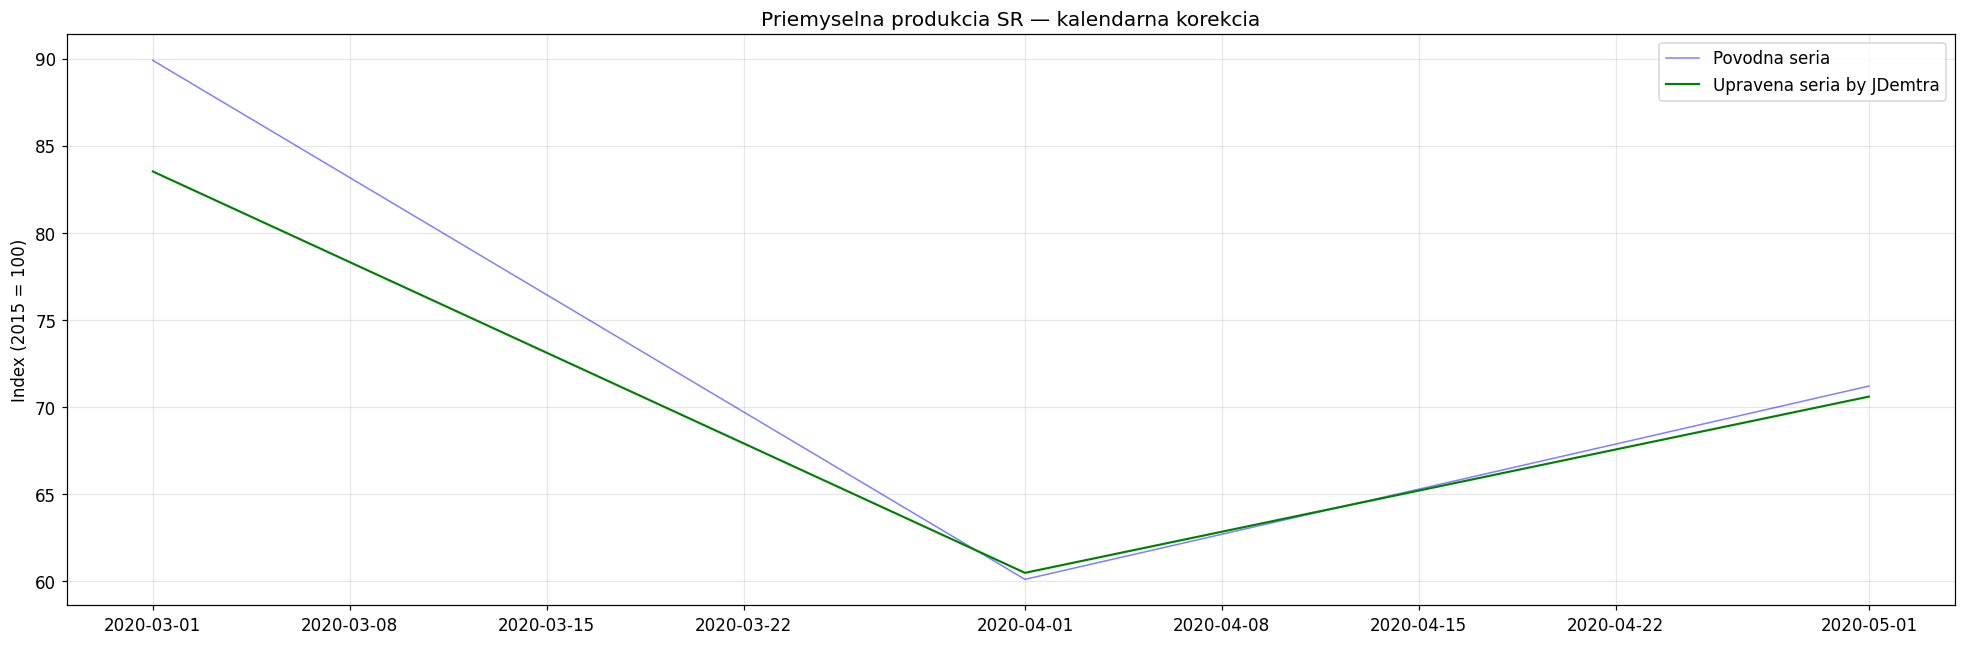

In [38]:
# graficke porovnanie casovych radov: povodne data vs. SA upravene cez SW JDemtra


fig, ax = plt.subplots()
ax.plot(df_subset.index, df_subset["pp_non_sa"],    color="blue",  linewidth=1,label="Povodna seria", alpha = 0.5)
ax.plot(df_subset.index, df_subset["pp_sa_ca_jd"], color = "green", linewidth = 1.4, label = "Upravena seria by JDemtra")
#ax.xaxis.set_major_formatter(mdates.DateFormatter("%m"))
ax.set_title("Priemyselna produkcia SR — kalendarna korekcia")
ax.set_ylabel("Index (2015 = 100)")
ax.legend()
plt.tight_layout()
#plt.savefig("figures/01_cielova_premenna.png", dpi=150)
plt.show()


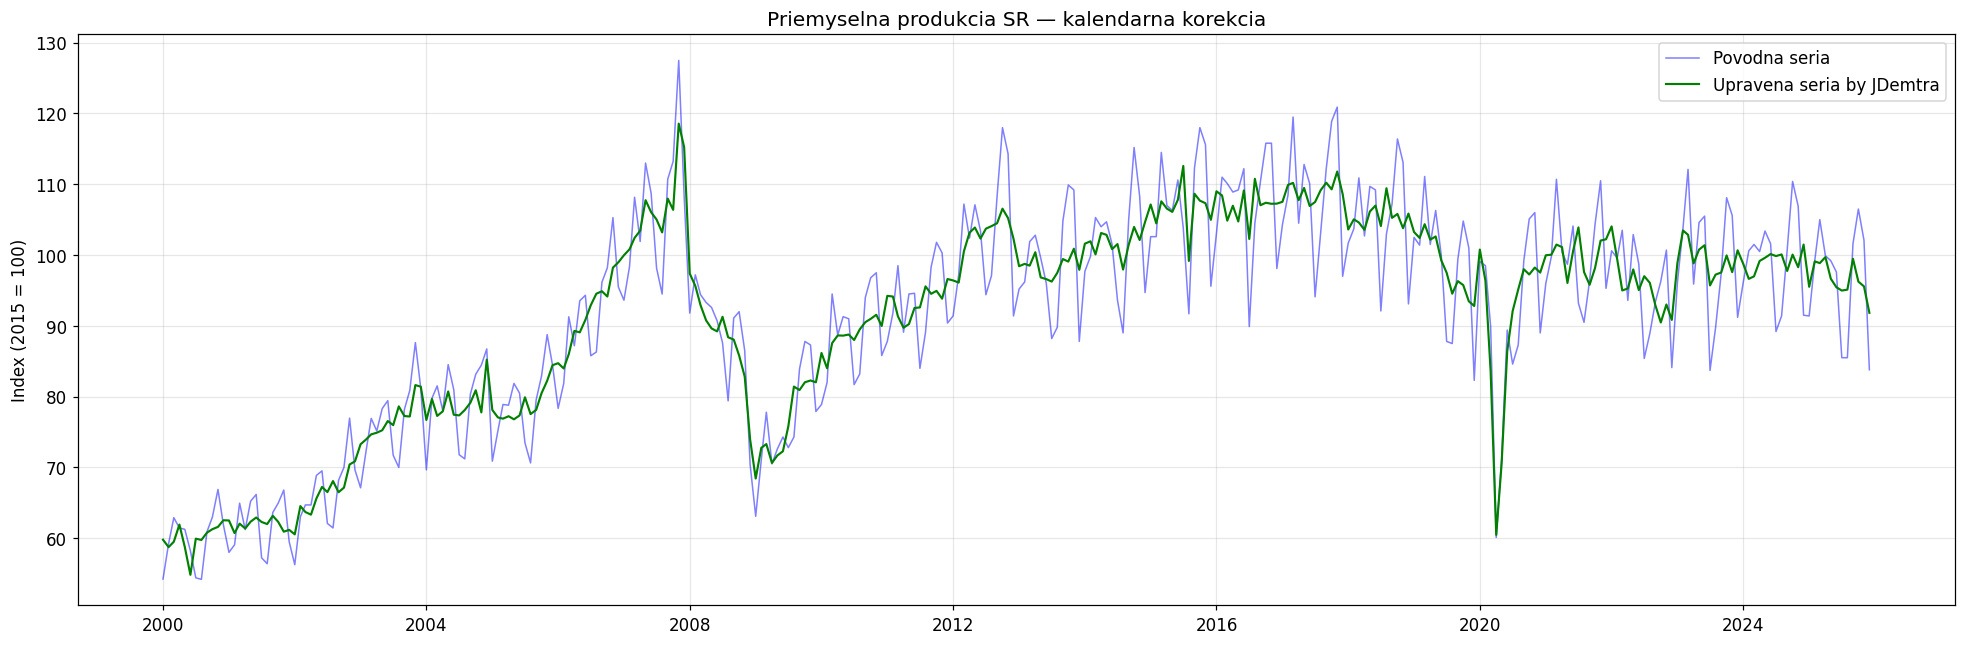

In [ ]:
# graficke porovnanie casovych radov: povodne data vs. SA upravene cez SW JDemtra


fig, ax = plt.subplots()
ax.plot(df.index, df["pp_non_sa"],    color="blue",  linewidth=1,label="Povodna seria", alpha = 0.5)
ax.plot(df.index, df["pp_sa_ca_jd"], color = "green", linewidth = 1.4, label = "Upravena seria by JDemtra")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title("Priemyselna produkcia SR — kalendarna korekcia")
ax.set_ylabel("Index (2015 = 100)")
ax.legend()
plt.tight_layout()
#plt.savefig("figures/01_cielova_premenna.png", dpi=150)
plt.show()


In [6]:
# 1. Tabuľka ADF + KPSS pre pôvodné úrovne
report_levels = check_stationarity(df)

print(
    report_levels[
        ["adf_pval", "kpss_pval", "verdict"]
    ].round(4)
)

# 2. Rozhodnutie: každá premenná dostane len 0 alebo 1
diff_orders = determine_diff_orders(
    df,
    alpha=0.05,
    verbose=True
)

print("\nFinalne rady diferencií:")
print(diff_orders)

# 3. Voliteľné manuálne úpravy.
# Povolené sú iba 0 alebo 1.
manual_overrides = {
    "infl_cpi": 1,
    "uvery_celkom": 1,
}

# 4. Finálny dataset
df_final = build_combined_dataset(
    df,
    diff_orders=diff_orders,
    manual_diff_order=manual_overrides,
)

print("\nPovodny pocet riadkov:", len(df))
print("Finalny pocet riadkov:", len(df_final))
print("Odstranene riadky:", len(df) - len(df_final))

print("\nPrve tri riadky df_final:")
print(df_final.head(3))

print("\nChybajuce hodnoty:")
print(df_final.isna().sum())

                               adf_pval  kpss_pval  \
premenna                                             
pp_non_sa                        0.0797     0.0100   
pp_sa_orig                       0.1212     0.0100   
cpi_non_sa                       0.9922     0.0100   
cpi_sa                           0.9948     0.0100   
infl_cpi                         0.9971     0.0100   
ipcv_priemysel                   0.7235     0.0100   
export_celkovy_sa                0.9126     0.0100   
trzby_priemysel_sa               0.8249     0.0100   
kurz_usd_eur                     0.1688     0.0480   
sadzba_3m_euribor                0.1657     0.0100   
uvery_celkom                     0.9984     0.0100   
vklady_nefinancne_podniky        0.9971     0.0100   
fin_stock                        0.0520     0.0172   
pp_sa_ca_jd                      0.1580     0.0100   
unem_prod                        0.5072     0.0100   
inflation                        0.0492     0.0562   
cdd                         

In [6]:
df_final.shape

(311, 30)

In [29]:
df_diff = df_final.copy()
df_diff["crisis_dummy"] = 0
df_diff.loc["2008-01-01", "crisis_dummy"] = 1

In [30]:
df_diff.columns

Index(['pp_non_sa', 'pp_sa_orig', 'cpi_non_sa', 'cpi_sa', 'infl_cpi',
       'ipcv_priemysel', 'export_celkovy_sa', 'trzby_priemysel_sa',
       'kurz_usd_eur', 'sadzba_3m_euribor', 'uvery_celkom',
       'vklady_nefinancne_podniky', 'fin_stock', 'pp_sa_ca_jd', 'unem_prod',
       'inflation', 'cdd', 'hdd', 'sh_prices_non_sa', 'economic_sentiment',
       'industry_confidence_sa', 'current_total_demand_sa',
       'foreign_demand_sa', 'finished_goods_inventories_sa',
       'expected_industry_production', 'expected_product_prices',
       'expected_employment', 'oil_europe_usd', 'oil_europe_eur',
       'crisis_dummy'],
      dtype='str')

In [31]:
df_diff = df_diff.reset_index()
df_diff.to_csv('../../../excel/data_mod.csv', index=False)